Fase 2: Análisis Estadístico

. Análisis de variables numéricas:

- Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes.
- Identificación de valores atípicos en las variables numéricas.
- Análisis de correlación entre variables numéricas --> se puede hacer una matriz de correlacion, por parejas, etc

.  Análisis de variables categóricas:
- Distribución de frecuencias de las variables categóricas relevantes. unic, value counts, que recuentos tengo para cada categoria

En todos los ejercicios, no te quedes solo en el “número”: añade siempre una breve interpretación en lenguaje natural, como lo haría un analista al presentar resultados a un equipo no técnico

In [2]:
import pandas as pd
import numpy as numpy
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_unido = pd.read_csv("documentos_unidos.csv")

In [5]:
# history
# numericas

df_unido.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
salary,403760.0,77932.277863,30076.538315,15609.00,64001.00,73510.00,82940.00,407228.00
clv,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38
enrollment_year,403760.0,2015.250716,1.979427,2012.00,2014.00,2015.00,2017.00,2018.00
enrollment_month,403760.0,6.667555,3.398829,1.00,4.00,7.00,10.00,12.00
is_active,403760.0,0.877031,0.328402,0.00,1.00,1.00,1.00,1.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00


<Axes: >

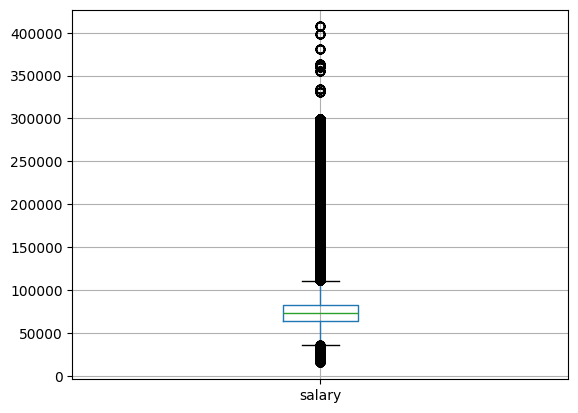

In [6]:
df_unido.boxplot(column=['salary'])

In [7]:
# categóricas

df_unido.describe(include="object").T

KeyboardInterrupt: 

In [8]:
df_unido.select_dtypes(include=["object", "category"]).columns

Index(['country', 'province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'enrollment_type',
       'cancellation_year', 'cancellation_month'],
      dtype='object')

In [ ]:
categorical_cols = df_history.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(f"\n### Distribución de {col}")
    print(df_history[col].value_counts(dropna=False))

In [ ]:
for col in categorical_cols:
    print(f"\n### Porcentaje de {col}")
    print(df_history[col].value_counts(normalize=True, dropna=False) * 100)

In [ ]:
"""# Conteo de cancelaciones por mes (solo filas con cancelación)
canceladas = df_history[df_history['is_active'] == 0]
counts = canceladas['cancellation_month_name'].value_counts().sort_index()
pct = counts / counts.sum() * 100

# Crosstab mes vs año de cancelación (proporciones por mes)
ct = pd.crosstab(canceladas['cancellation_month_name'], canceladas['cancellation_year'], normalize='index')*100

# Chi-square (ejemplo)
from scipy.stats import chi2_contingency
table = pd.crosstab(canceladas['cancellation_month_name'], canceladas['some_category'])
chi2, p, dof, expected = chi2_contingency(table.fillna(0))